# Two-locus Island model

In [1]:
from phasic import (
    Graph, with_ipv, set_log_level,
    StateIndexer, PropertySet, Property,
    GaussPrior, HalfCauchyPrior, ExpStepSize, ExpRegularization, 
    GraphCache, clear_caches, clear_jax_cache, clear_model_cache,
)
import numpy as np
import jax.numpy as jnp
import pandas as pd
from itertools import combinations_with_replacement as combs
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from vscodenb import set_vscode_theme

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

set_log_level('DEBUG') 

from phasic import GraphCache                                                              
                                                                                                         
graph_cache = GraphCache() 

[DEBUG] phasic.graph_cache: GraphCache initialized: /Users/kmt/.phasic_cache/graphs


## Simple single-locus two-island model for testing

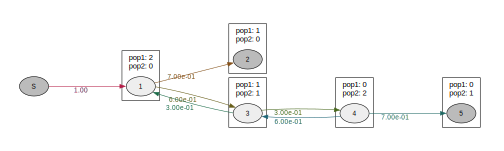

In [25]:
nr_samples = 2

indexer = StateIndexer(
    descendants=[
    Property('pop1', min_value=0, max_value=nr_samples),
    Property('pop2', min_value=0, max_value=nr_samples),
    Property('in_pop', min_value=1, max_value=2),
])

initial = [0] * indexer.state_length

# set initial state with all lineages having one descendant at both loci
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def two_island(state):
    transitions = []

    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)

        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            
            if props_j.in_pop != props_i.in_pop:
                continue

            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 

            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_pop1 = props_i.pop1 + props_j.pop1
            des_pop2 = props_i.pop2 + props_j.pop2
            if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
                k = indexer.descendants.props_to_index(
                    pop1=des_pop1, 
                    pop2=des_pop2, 
                    in_pop=props_i.in_pop
                    )
                child[k] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child = state.copy()
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                pop1=props_i.pop1, 
                pop2=props_i.pop2, 
                in_pop=other_pop
                )
            child[k] += 1

            transitions.append([child, [0, state[i]]])

    return transitions

graph = Graph(two_island)   

true_theta = [0.7, 0.3]
graph.update_weights(true_theta)

def label(state):
    nr_pop1 = sum([state[i] * bool(indexer.index_to_props(i).descendants.in_pop == 1) for i in indexer])
    nr_pop2 = sum([state[i] * bool(indexer.index_to_props(i).descendants.in_pop == 2) for i in indexer])
    return f"pop1: {nr_pop1}\npop2: {nr_pop2}"

graph.plot(rankdir='LR', nodesep=0.3, ranksep=2,
                      wrap=10, 
                      label_fmt=False, by_state=label)

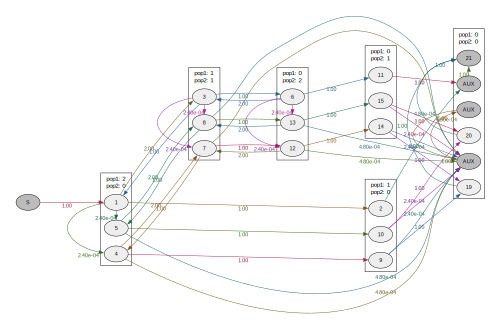

In [26]:
mutation_rate = 1.2e-4
joint_prob_graph = graph.joint_prob_graph(indexer, 
                                          reward_only=['pop1', 'pop2'],
                                          reward_limit=1,
                                          tot_reward_limit=1, 
                                          mutation_rate=mutation_rate)

joint_prob_graph.plot(rankdir='LR', nodesep=0.3, ranksep=2,
                      wrap=10, label_fmt=False, by_state=label)

In [5]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,pop1_0,pop1_1,pop1_2,pop2_0,pop2_1,pop2_2,prob
t_vertex_index,,,,,,,
18,0,0,0,0,0,0,0.999041
19,0,1,0,0,0,0,0.000479
20,0,0,0,1,0,0,0.000479


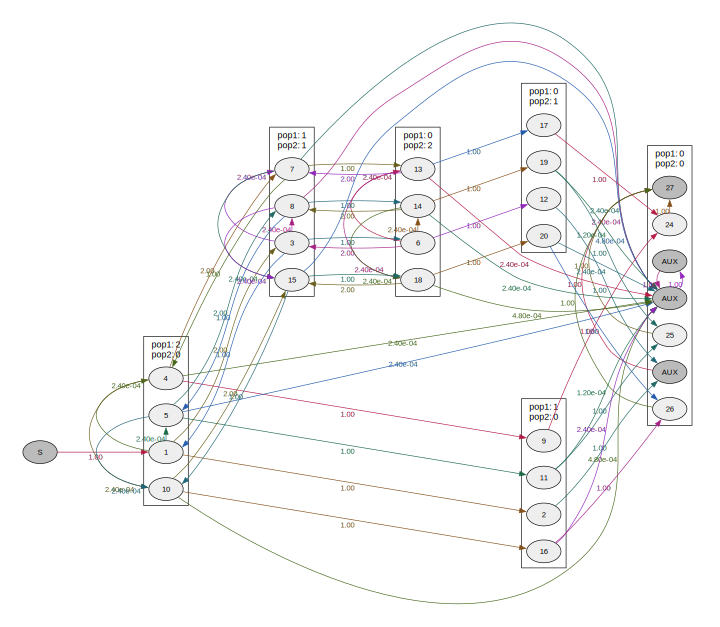

In [9]:
mutation_rate = 1.2e-4
joint_prob_graph = graph.joint_prob_graph(indexer,
                                         reward_only=['pop1', 'pop2'],
                               reward_limit=1, 
                               tot_reward_limit=2, 
                               mutation_rate=mutation_rate
                               )
joint_prob_graph.vertices_length() 

joint_prob_graph.plot(rankdir='LR', size=(10,10),
           max_nodes=700,
           nodesep=0.3,
           ranksep=2,
           wrap=10,
#           fontsize=30,
            label_fmt=False,
            by_state=label,
            
            
            )                              

In [10]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,pop1_0,pop1_1,pop1_2,pop2_0,pop2_1,pop2_2,prob
t_vertex_index,,,,,,,
23,0,0,0,0,0,0,9.990410e-01
24,0,1,0,0,0,0,4.789649e-04
25,0,0,0,1,0,0,4.789074e-04
26,0,1,0,1,0,0,5.165794e-07


deficit:

In [11]:
1 - joint_prob_table.prob.sum()

np.float64(5.754260877788298e-07)

## Two population ghost model

47


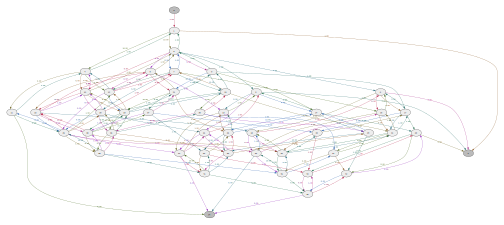

In [28]:

def two_locus_ghost_island(state, epoch_idx=None, epoch_start=None, nr_epochs=None, nr_params=None, indexer=None):

    coef_len = int(nr_params * nr_epochs + 1 + 1) 
    # +1 to have a slot for mutation rate scalar
    # +1 to have a slot for transitions between epochs

    pop1_coal_idx = int(epoch_idx * nr_params + 0)
    pop1_rec_idx =  int(epoch_idx * nr_params + 1)
    pop1_mig_idx =  int(epoch_idx * nr_params + 2)
    pop2_coal_idx = int(epoch_idx * nr_params + 3)
    pop2_rec_idx =  int(epoch_idx * nr_params + 4)
    pop2_mig_idx =  int(epoch_idx * nr_params + 5)


    transitions = []

    # nonzero_idx = np.nonzero(state)[0]
    nonzero_idx = np.nonzero(state[:indexer.descendants.state_length])[0]

    # if state.sum() > 2*nr_samples:
    #     print('>>>', sum(state))
    #     for idx in np.nonzero(state)[0]:
    #         p = indexer.descendants.index_to_props(idx)
    #         print('>>>', state[idx], p)
    #     return
    
    if state.sum() <= 1: return transitions
    
    for i, j in combs(nonzero_idx, 2):

    # for i in range(indexer.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        
        # for j in range(i, indexer.state_length):
        if state[j] == 0: continue
        props_j = indexer.descendants.index_to_props(j)

        if props_j.in_pop != props_i.in_pop:
            # skip if in different pops            
            continue

        same = int(i == j)
        if same and state[i] < 2:
            # skip if same and less than two lineages
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            # skip if different and either kind has no lineages
            continue 

        # coalescence
        loc1=props_i.loc1 + props_j.loc1
        loc2=props_i.loc2 + props_j.loc2
        if loc1 <= nr_samples and loc2 <= nr_samples:
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            k = indexer.descendants.props_to_index(
                loc1=props_i.loc1 + props_j.loc1,
                loc2=props_i.loc2 + props_j.loc2,
                in_pop=props_i.in_pop
                )
            child[k] += 1
            # validate(child, indexer, state)

            coef = np.zeros(coef_len) # +1 to have a slot for transitions between epochs
            if props_i.in_pop == 1:
                coef[pop1_coal_idx] = state[i]*(state[j]-same)/(1+same)
            else:
                coef[pop2_coal_idx] = state[i]*(state[j]-same)/(1+same)
            transitions.append([child, coef])

            # transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0, 0]])

    for i in nonzero_idx:
        props_i = indexer.descendants.index_to_props(i)
        
        # recombination
        loc1 = props_i.loc1 
        loc2 = props_i.loc2
        if state[i] > 0 and 0 < loc1 <= nr_samples and 0 < loc2 <= nr_samples:
            child = state.copy()
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                loc1=0,
                loc2=props_i.loc2, 
                in_pop=props_i.in_pop
                )
            child[k] += 1
            k = indexer.descendants.props_to_index(
                loc1=props_i.loc1,
                loc2=0, 
                in_pop=props_i.in_pop
                )
            child[k] += 1
            # validate(child, indexer, state)
            coef = np.zeros(coef_len) # +1 to have a slot for transitions between epochs
            if props_i.in_pop == 1:
                coef[pop1_rec_idx] = state[i]
            else:
                coef[pop2_rec_idx] = state[i]
            transitions.append([child, coef])            
#            transitions.append([child, [0, state[i], 0]])

        # migration
        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child = state.copy()
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                loc1=props_i.loc1,
                loc2=props_i.loc2, 
                in_pop=other_pop
                )
            child[k] += 1
            # validate(child, indexer, state)
            coef = np.zeros(coef_len) # +1 to have a slot for transitions between epochs
            if props_i.in_pop == 2:
                 coef[pop1_mig_idx] = state[i]
            else:
                coef[pop2_mig_idx] = state[i]
            transitions.append([child, coef])                      
            # transitions.append([child, [0, 0, state[i]]])

    return transitions


# def add_epoch(graph, callback, epochs, epoch_idx, indexer):
def add_epoch(graph, callback, epoch_idx=None, epoch_start = None, nr_epochs=None, nr_params=None, indexer=None):

    epoch = epoch_start
    # epoch = epochs[epoch_idx]

    coef_len = int(nr_params * nr_epochs + 1 + 1) 
    # +1 to have a slot for mutation rate scalar
    # +1 to have a slot for transitions between epochs


    stop_probs = np.array(graph.stop_probability(epoch))
    accum_v_time = np.array(graph.accumulated_occupancy(epoch))

    with np.errstate(invalid='ignore'):
        epoch_trans_rates = stop_probs / accum_v_time

    for i in range(1, graph.vertices_length()-1):

        if epoch_trans_rates is None or np.isnan(epoch_trans_rates[i]):
            continue        
        if graph.vertex_at(i).edges_length() == 0:
            continue

        vertex = graph.vertex_at(i)
        state = vertex.state()

        if not state[indexer.epoch] == epoch_idx - 1:
            continue

        sister_state = state.copy()
        sister_state[indexer.epoch] = epoch_idx        
        child = graph.find_or_create_vertex(sister_state)
        coeff = np.zeros(coef_len)
        coeff[-1] = epoch_trans_rates[i]
        vertex.add_edge(child, coeff)

    # graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)
    graph.extend(callback, epoch_idx=epoch_idx, nr_epochs=nr_epochs, nr_params=nr_params, indexer=indexer)   


nr_samples = 2
epochs = [0, 1]
true_theta = [
    # epoch 1: pop1 coal, rec, mig, pop2 coal, rec, mig
    1, 5, 1, 5, 1, 5, 
    # epoch 2: pop1 coal, rec, mig, pop2 coal, rec, mig
    1, 1, 1, 1, 1, 1, 
    0, # +1 for mutation rate scalar
    1  # +1 for epoch transition rate
]



# true_theta = pop1_coal_rates + pop1_rec_rates + pop1_mig_rates + \
#     pop2_coal_rates + pop2_rec_rates + pop2_mig_rates + \
#     [0, 1]
#     # +1 for mutation rate scalar
#     # +1 for epoch transition rate

coef_len = len(true_theta)

indexer = StateIndexer(
    descendants=[        
        Property('loc1', min_value=0, max_value=nr_samples),
        Property('loc2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ],
    slots=['epoch'] 
)
indexer.state_length
initial = [0] * indexer.state_length

# set initial state with all lineages having one descendant at both loci
initial[indexer.descendants.props_to_index(loc1=1, loc2=1, in_pop=1, 
                                           #epoch=0
                                           )] = nr_samples



#graph = Graph(two_locus_ghost_island, ipv=initial, epochs=epochs, epoch_idx=0, indexer=indexer)   
graph = Graph(two_locus_ghost_island, ipv=initial, epoch_idx=0, nr_epochs=2, nr_params=6, indexer=indexer)   

# graph_cache.save_graph(graph, two_locus_ghost_island, epoch_idx=0, nr_epochs=2, nr_params=6, indexer=indexer)  

graph.update_weights(true_theta)
print(graph.vertices_length())
graph.plot(rankdir='TB',# size=(12,8),
           max_nodes=200,
           label_fmt=False,
            )

In [29]:
mutation_rate = 1.2e-4

joint_prob_graph = graph.joint_prob_graph(indexer,
                                          reward_only=['loc1', 'loc2'],
                               reward_limit=1, 
                               tot_reward_limit=2, 
                               mutation_rate=mutation_rate
                               )
joint_prob_graph.vertices_length()

698

In [30]:
joint_prob_graph.plot(rankdir='TB', size=(10,10),
           nodesep=0.1,
           ranksep=5,
           max_nodes=700,
           wrap=10,
           label_fmt=lambda state: None
            )


In [31]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,loc1_0,loc1_1,loc1_2,loc2_0,loc2_1,loc2_2,prob
t_vertex_index,,,,,,,
675,0,0,0,0,0,0,9.979723e-01
676,0,1,0,0,0,0,4.782476e-04
677,0,0,0,0,1,0,4.782476e-04
678,0,1,0,0,1,0,3.171944e-07
679,1,0,0,0,0,0,3.618324e-04
680,0,0,1,0,0,0,1.716985e-04
681,0,0,0,1,0,0,3.618324e-04
682,0,0,0,0,0,1,1.716985e-04
683,1,0,1,0,0,0,1.807664e-07


In [42]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "ton"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                          demography=demography, recombination_rate=rec_rate, 
                          sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("island_model_derived_counts.csv", index=False)

In [56]:
tons[dist:].shape

(99999000,)

In [58]:
tons = np.zeros(seq_length, dtype=int)
tons[df.pos] = df.ton
dist = 1000
a = np.stack(
    [tons[:-dist],
    tons[dist:]],
      axis=0).T
a

array([[0, 0],
       [0, 0],
       [0, 0],
       ...,
       [0, 0],
       [0, 0],
       [0, 0]], shape=(99999000, 2))

In [38]:
df

,pos,gen_pos,count
0,156889,0.001569,3
1,160020,0.001600,1
2,164783,0.001648,3
3,193571,0.001936,2
4,201980,0.002020,3
...,...,...,...
5474,99970995,0.999710,1
5475,99979555,0.999796,3
5476,99989206,0.999892,1
5477,99989429,0.999894,1


Get pairs of variants in the specified distance range.

In [33]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df = pd.read_csv("island_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


We allow multiple SNPs from the same tree, but each SNP can only be part of a single pair. Remove pairs that share a position with another pair:

In [37]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1
...,...,...,...,...
305,97469875,97475315,3,1
306,98026696,98031280,3,2
307,98957083,98961654,4,1
309,99382200,99387696,1,1


Plot position differences for pairs of variants:

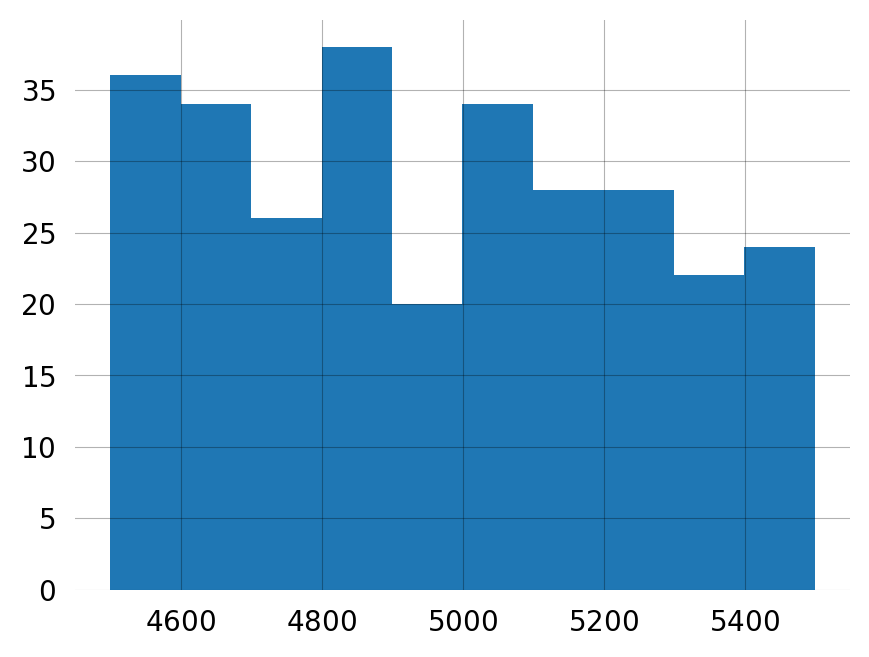

In [36]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

## IM ghost model

In [ ]:
#graph = Graph(two_locus_ghost_island, ipv=initial, epochs=epochs, epoch_idx=0, indexer=indexer)   
graph = Graph(two_locus_ghost_island, ipv=initial, epoch_idx=0, nr_epochs=2, nr_params=6, indexer=indexer)   

# graph_cache.save_graph(graph, two_locus_ghost_island, epoch_idx=0, nr_epochs=2, nr_params=6, indexer=indexer)  

print(graph.vertices_length())
graph.plot(rankdir='TB', size=(12,8),
           max_nodes=200,
           wrap=10,
            # label_fmt=lambda state: None
            )

Add the second epoch:

In [10]:
graph.update_weights(true_theta)
for epoch_idx in range(1, len(epochs)):
    graph.update_weights(true_theta)
    # add_epoch(graph, two_locus_island, epochs, epoch_idx, indexer)
    add_epoch(graph, two_locus_ghost_island, epoch_idx=epoch_idx, nr_epochs=2, epoch_start=epochs[epoch_idx], nr_params=6, indexer=indexer)

graph.update_weights(true_theta)
graph.plot(rankdir='TB', size=(12,8),
           max_nodes=200,
           label_fmt=lambda state: None
            )

[DEBUG] phasic.c: Auto-selected granularity: 1024 (max_rate=512.00)


Graph has too many nodes (2863). Please set max_nodes to a higher value.


In [12]:
mutation_rate = 1.2e-4

joint_prob_graph = graph.joint_prob_graph(indexer,
                                          reward_only=['loc1', 'loc2'],
                               reward_limit=1, 
                               tot_reward_limit=2, 
                               mutation_rate=mutation_rate
                               )
joint_prob_graph.vertices_length()                               

66490

In [ ]:
joint_prob_graph.plot(rankdir='LR', size=(10,10),
           nodesep=0.1,
           ranksep=3,
           wrap=10,
            # label_fmt=lambda state: None
            )

Graph has too many nodes (66490). Please set max_nodes to a higher value.


: 

In [ ]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

In [ ]:
joint_prob_graph.vertices_length()  

## Sampling from both populations

In [ ]:
#clear_caches(verbose=True)



# def validate(child, indexer, state):
#     loc1_total = 0
#     loc2_total = 0    
#     for i in range(indexer.state_length):
#         p = indexer.descendants.index_to_props(i)
#         loc1_total += child[i] * (p.loc1pop1 + p.loc1pop2)
#         loc2_total += child[i] * (p.loc2pop1 + p.loc2pop2)

#     if loc1_total > nr_samples or loc2_total > nr_samples:
#         print('STATE')
#         for idx in np.nonzero(state)[0]:
#             p = indexer.descendants.index_to_props(idx)
#             print('>>>', idx, state[idx], p)
#         print('CHILD')
#         for idx in np.nonzero(child)[0]:
#             p = indexer.descendants.index_to_props(idx)
#             print('>>>', idx, child[idx], p)
#         raise ValueError(f"State has more lineages than possible: {child}: {loc1_total} {loc2_total}")


# def two_locus_island(state, epochs=None, epoch_idx=None, indexer=None):
#     nr_params = 6
#     coef_len = nr_params * len(epochs) + 1 # +1 to have a slot for transitions between epochs   

def two_locus_island(state, epoch_idx=None, epoch_start=None, nr_epochs=None, nr_params=None, indexer=None):

    coef_len = int(nr_params * nr_epochs + 1 + 1) 
    # +1 to have a slot for mutation rate scalar
    # +1 to have a slot for transitions between epochs

    pop1_coal_idx = int(epoch_idx * nr_params + 0)
    pop1_rec_idx =  int(epoch_idx * nr_params + 1)
    pop1_mig_idx =  int(epoch_idx * nr_params + 2)
    pop2_coal_idx = int(epoch_idx * nr_params + 3)
    pop2_rec_idx =  int(epoch_idx * nr_params + 4)
    pop2_mig_idx =  int(epoch_idx * nr_params + 5)


    transitions = []

    # nonzero_idx = np.nonzero(state)[0]
    nonzero_idx = np.nonzero(state[:indexer.descendants.state_length])[0]

    # if state.sum() > 2*nr_samples:
    #     print('>>>', sum(state))
    #     for idx in np.nonzero(state)[0]:
    #         p = indexer.descendants.index_to_props(idx)
    #         print('>>>', state[idx], p)
    #     return
    
    if state.sum() <= 1: return transitions
    
    for i, j in combs(nonzero_idx, 2):

    # for i in range(indexer.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        
        # for j in range(i, indexer.state_length):
        if state[j] == 0: continue
        props_j = indexer.descendants.index_to_props(j)

        if props_j.in_pop != props_i.in_pop:
            # skip if in different pops            
            continue

        same = int(i == j)
        if same and state[i] < 2:
            # skip if same and less than two lineages
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            # skip if different and either kind has no lineages
            continue 

        # coalescence
        loc1pop1=props_i.loc1pop1 + props_j.loc1pop1
        loc1pop2=props_i.loc1pop2 + props_j.loc1pop2
        loc2pop1=props_i.loc2pop1 + props_j.loc2pop1
        loc2pop2=props_i.loc2pop2 + props_j.loc2pop2
        if loc1pop1 + loc1pop2 <= nr_samples and loc2pop1 + loc2pop2 <= nr_samples:
            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            k = indexer.descendants.props_to_index(
                loc1pop1=props_i.loc1pop1 + props_j.loc1pop1,
                loc1pop2=props_i.loc1pop2 + props_j.loc1pop2,
                loc2pop1=props_i.loc2pop1 + props_j.loc2pop1,
                loc2pop2=props_i.loc2pop2 + props_j.loc2pop2,
                in_pop=props_i.in_pop
                )
            child[k] += 1
            # validate(child, indexer, state)

            coef = np.zeros(coef_len) # +1 to have a slot for transitions between epochs
            if props_i.in_pop == 1:
                coef[pop1_coal_idx] = state[i]*(state[j]-same)/(1+same)
            else:
                coef[pop2_coal_idx] = state[i]*(state[j]-same)/(1+same)
            transitions.append([child, coef])

            # transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0, 0]])

    for i in nonzero_idx:
        props_i = indexer.descendants.index_to_props(i)
        
        # recombination
        loc1 = props_i.loc1pop1 + props_i.loc1pop2
        loc2 = props_i.loc2pop1 + props_i.loc2pop2
        if state[i] > 0 and 0 < loc1 <= nr_samples and 0 < loc2 <= nr_samples:
            child = state.copy()
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                loc1pop1=0,
                loc1pop2=0,
                loc2pop1=props_i.loc2pop1, 
                loc2pop2=props_i.loc2pop2, 
                in_pop=props_i.in_pop
                )
            child[k] += 1
            k = indexer.descendants.props_to_index(
                loc1pop1=props_i.loc1pop1,
                loc1pop2=props_i.loc1pop2,
                loc2pop1=0, 
                loc2pop2=0, 
                in_pop=props_i.in_pop
                )
            child[k] += 1
            # validate(child, indexer, state)
            coef = np.zeros(coef_len) # +1 to have a slot for transitions between epochs
            if props_i.in_pop == 1:
                coef[pop1_rec_idx] = state[i]
            else:
                coef[pop2_rec_idx] = state[i]
            transitions.append([child, coef])            
#            transitions.append([child, [0, state[i], 0]])

        # migration
        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child = state.copy()
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                loc1pop1=props_i.loc1pop1,
                loc1pop2=props_i.loc1pop2,
                loc2pop1=props_i.loc2pop1, 
                loc2pop2=props_i.loc2pop2, 
                in_pop=other_pop
                )
            child[k] += 1
            # validate(child, indexer, state)
            coef = np.zeros(coef_len) # +1 to have a slot for transitions between epochs
            if props_i.in_pop == 2:
                 coef[pop1_mig_idx] = state[i]
            else:
                coef[pop2_mig_idx] = state[i]
            transitions.append([child, coef])                      
            # transitions.append([child, [0, 0, state[i]]])

    return transitions


# def add_epoch(graph, callback, epochs, epoch_idx, indexer):
def add_epoch(graph, callback, epoch_idx=None, epoch_start = None, nr_epochs=None, nr_params=None, indexer=None):

    epoch = epoch_start
    # epoch = epochs[epoch_idx]

    coef_len = int(nr_params * nr_epochs + 1 + 1) 
    # +1 to have a slot for mutation rate scalar
    # +1 to have a slot for transitions between epochs


    stop_probs = np.array(graph.stop_probability(epoch))
    accum_v_time = np.array(graph.accumulated_occupancy(epoch))

    with np.errstate(invalid='ignore'):
        epoch_trans_rates = stop_probs / accum_v_time

    for i in range(1, graph.vertices_length()-1):

        if epoch_trans_rates is None or np.isnan(epoch_trans_rates[i]):
            continue        
        if graph.vertex_at(i).edges_length() == 0:
            continue

        vertex = graph.vertex_at(i)
        state = vertex.state()

        if not state[indexer.epoch] == epoch_idx - 1:
            continue

        sister_state = state.copy()
        sister_state[indexer.epoch] = epoch_idx        
        child = graph.find_or_create_vertex(sister_state)
        coeff = np.zeros(coef_len)
        coeff[-1] = epoch_trans_rates[i]
        vertex.add_edge(child, coeff)

    # graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)
    graph.extend(callback, epoch_idx=epoch_idx, nr_epochs=nr_epochs, nr_params=nr_params, indexer=indexer)   


nr_samples = 2
epochs = [0, 1]
true_theta = [
    # epoch 1: pop1 coal, rec, mig, pop2 coal, rec, mig
    1, 5, 1, 5, 1, 5, 
    # epoch 2: pop1 coal, rec, mig, pop2 coal, rec, mig
    1, 1, 1, 1, 1, 1, 
    0, # +1 for mutation rate scalar
    1  # +1 for epoch transition rate
]
# pop1_coal_rates = [1, 5]
# pop2_coal_rates = [1, 5]
# pop1_rec_rates = [1, 1]
# pop2_rec_rates = [1, 1]
# pop1_mig_rates = [1, 1]
# pop2_mig_rates = [1, 1]
# pop1_coal_rates = [1, 5]
# pop2_coal_rates = [1, 5]
# pop1_rec_rates = [1, 1]
# pop2_rec_rates = [1, 1]
# pop1_mig_rates = [1, 1]
# pop2_mig_rates = [1, 1]


# true_theta = pop1_coal_rates + pop1_rec_rates + pop1_mig_rates + \
#     pop2_coal_rates + pop2_rec_rates + pop2_mig_rates + \
#     [0, 1]
#     # +1 for mutation rate scalar
#     # +1 for epoch transition rate

coef_len = len(true_theta)

indexer = StateIndexer(
    descendants=[        
        Property('loc1pop1', min_value=0, max_value=nr_samples),
        Property('loc1pop2', min_value=0, max_value=nr_samples),
        Property('loc2pop1', min_value=0, max_value=nr_samples),
        Property('loc2pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ],
    slots=['epoch'] 
)
indexer.state_length
initial = [0] * indexer.state_length

# set initial state with all lineages having one descendant at both loci
initial[indexer.descendants.props_to_index(loc1pop1=1, loc1pop2=0, loc2pop1=1, loc2pop2=0, in_pop=1, 
                                           #epoch=1
                                           )] = nr_samples

from itertools import combinations_with_replacement as combs


#graph = Graph(two_locus_island, ipv=initial, epochs=epochs, epoch_idx=0, indexer=indexer)   
graph = Graph(two_locus_island, ipv=initial, epoch_idx=0, nr_epochs=2, nr_params=6, indexer=indexer)   

# graph_cache.save_graph(graph, two_locus_island, epoch_idx=0, nr_epochs=2, nr_params=6, indexer=indexer)  

print(graph.vertices_length())
graph.plot(rankdir='TB', size=(12,8),
           max_nodes=200,
           wrap=10,
            # label_fmt=lambda state: None
            )

In [ ]:
graph.update_weights(true_theta)
for epoch_idx in range(1, len(epochs)):
    graph.update_weights(true_theta)
    # add_epoch(graph, two_locus_island, epochs, epoch_idx, indexer)
    add_epoch(graph, two_locus_island, epoch_idx=epoch_idx, nr_epochs=2, epoch_start=epochs[epoch_idx], nr_params=6, indexer=indexer)

graph.update_weights(true_theta)
graph.plot(rankdir='TB', size=(12,8),
           max_nodes=200,
            label_fmt=lambda state: None
            )

In [ ]:
# def mutation_coef(state):
#     nr_lineages = sum(state)
#     coef = np.zeros(coef_len) # +1 to have a slot for transitions between epochs
#     coef[-2] = nr_lineages # mutation rate scalar is at the second to last position in the coefficient vector
#     return coef

# aux_rewards = graph.discretize(mutation_coef)

# graph.plot(rankdir='TB', size=(12,8),
#            max_nodes=200,
#             label_fmt=lambda state: None
#             )

In [ ]:
%%monitor 

mutation_rate = 1
joint_prob_graph = graph.joint_prob_graph(indexer,
                               tot_reward_limit=2, 
                               mutation_rate=mutation_rate
                               )

In [ ]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

In [ ]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                          demography=demography, recombination_rate=rec_rate, 
                          sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("island_model_derived_counts.csv", index=False)

In [ ]:
# # isolation with migration (IM) model:
# demography = msprime.Demography()
# demography.add_population(name="pop1", initial_size=pop1_size)
# demography.add_population(name="pop2", initial_size=pop2_size)
# demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
# demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
# demography.add_population(name="ancestral", initial_size=anc_pop_size)
# demography.add_population_split(time=1000, derived=["pop1", "pop2"], ancestral="ancestral")
# ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
#                           demography=demography, recombination_rate=rec_rate, 
#                           sequence_length=seq_length, random_seed=12)
# ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
# df = derived_counts(ts, rec_rate)
# df.to_csv("IM_model_derived_counts.csv", index=False)

Get pairs of variants in the specified distance range.

In [ ]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df = pd.read_csv("island_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


We allow multiple SNPs from the same tree, but each SNP can only be part of a single pair. Remove pairs that share a position with another pair:

In [ ]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


Plot position differences for pairs of variants:

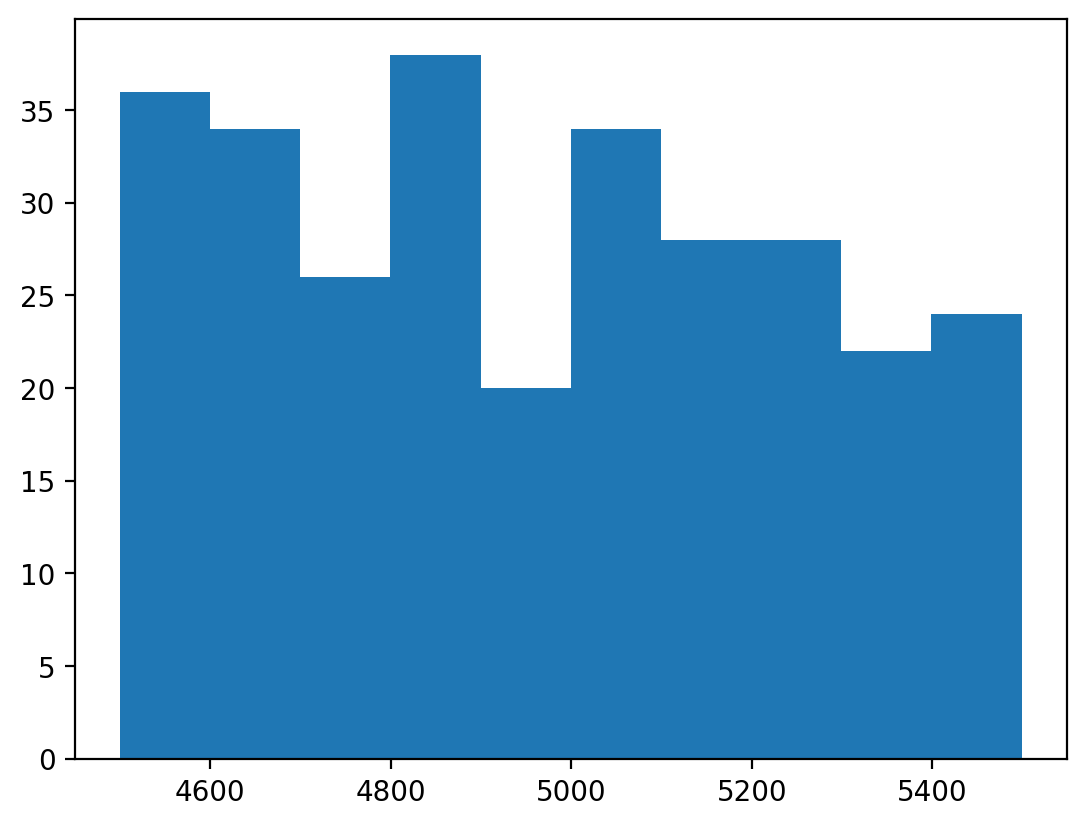

In [ ]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [ ]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [ ]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005

